1) **IMPORT PACKAGE PYTHON**


In [ ]:
# ====== IMPORT LIBRARY ======
import numpy as np   #mengolah data yang berbentuk array
import pandas as pd  #membaca file csv dan display dalam bentuk tabel
import matplotlib.pyplot as plt  #digunakan untuk visualisasi data
from scipy.sparse import data

# ====== Membuat Plot dalam Bentuk Diagram Batang ======
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# ====== Silhouette Score ======
from sklearn.metrics import silhouette_score   #digunakan untuk mengukur kualitas cluster yang terbentuk

# ====== Standard Scaler ======
#untuk melakukan preprocessing, menyeragamkan rentang nilai data pada dataset
from sklearn.preprocessing import StandardScaler

# Fungsi untuk reduksi fitur data sehingga dapat dilakukan visualisasi 2 dimensi
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

2) **IMPORT DATASET**


In [ ]:
dataset=pd.read_csv('CC GENERAL.csv')
print(dataset)

     CUST_ID      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0     C10001    40.900749           0.818182      95.40              0.00   
1     C10002  3202.467416           0.909091       0.00              0.00   
2     C10003  2495.148862           1.000000     773.17            773.17   
3     C10004  1666.670542           0.636364    1499.00           1499.00   
4     C10005   817.714335           1.000000      16.00             16.00   
...      ...          ...                ...        ...               ...   
8945  C19186    28.493517           1.000000     291.12              0.00   
8946  C19187    19.183215           1.000000     300.00              0.00   
8947  C19188    23.398673           0.833333     144.40              0.00   
8948  C19189    13.457564           0.833333       0.00              0.00   
8949  C19190   372.708075           0.666667    1093.25           1093.25   

      INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0       

3) **PREPROCESSING DATA**

In [ ]:
# Menghapus kolom cust_id
dataset.drop('CUST_ID', axis = 1, inplace = True)

# Pengecekan nilai null (kosong) pada dataset
dataset.isnull().sum().sort_values(ascending=False).head()

MINIMUM_PAYMENTS          313
CREDIT_LIMIT                1
BALANCE                     0
CASH_ADVANCE_FREQUENCY      0
PRC_FULL_PAYMENT            0
dtype: int64

Terdapat 313 nilai null (kosong) pada variabel MINIMUM_PAYMENTS dan 1 nilai null (kosong) pada variabel CREDIT_LIMIT


In [ ]:
# Mengisi nilai null dengan nilai rata-rata pada kolom tersebut
dataset['CREDIT_LIMIT'] = dataset['CREDIT_LIMIT'].fillna(dataset['CREDIT_LIMIT'].mean())
dataset['MINIMUM_PAYMENTS'] = dataset['MINIMUM_PAYMENTS'].fillna(dataset['MINIMUM_PAYMENTS'].mean())
len(dataset.columns[dataset.isnull().any()])
dataset.isnull().sum().sort_values(ascending=False).head()

BALANCE                   0
CASH_ADVANCE_FREQUENCY    0
PRC_FULL_PAYMENT          0
MINIMUM_PAYMENTS          0
PAYMENTS                  0
dtype: int64

Setelah dilakukan pengisian nilai menggunakan nilai rata-rata, maka semua kolom sudah terisi dan tidak ada kolom yang nilainya null (kosong)

In [ ]:
# Standarisasi nilai
scaler = StandardScaler()
scaled_data = scaler.fit_transform(dataset)

df = pd.DataFrame(scaled_data, columns=dataset.columns)
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960433,-0.528979,-3.109675e-01,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688639,0.818642,8.931021e-02,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826062,-0.383805,-1.016632e-01,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826062,-0.598688,4.878305e-17,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905464,-0.364368,-2.657913e-01,-0.525551,0.36068


4) **PROCESSING DATA**

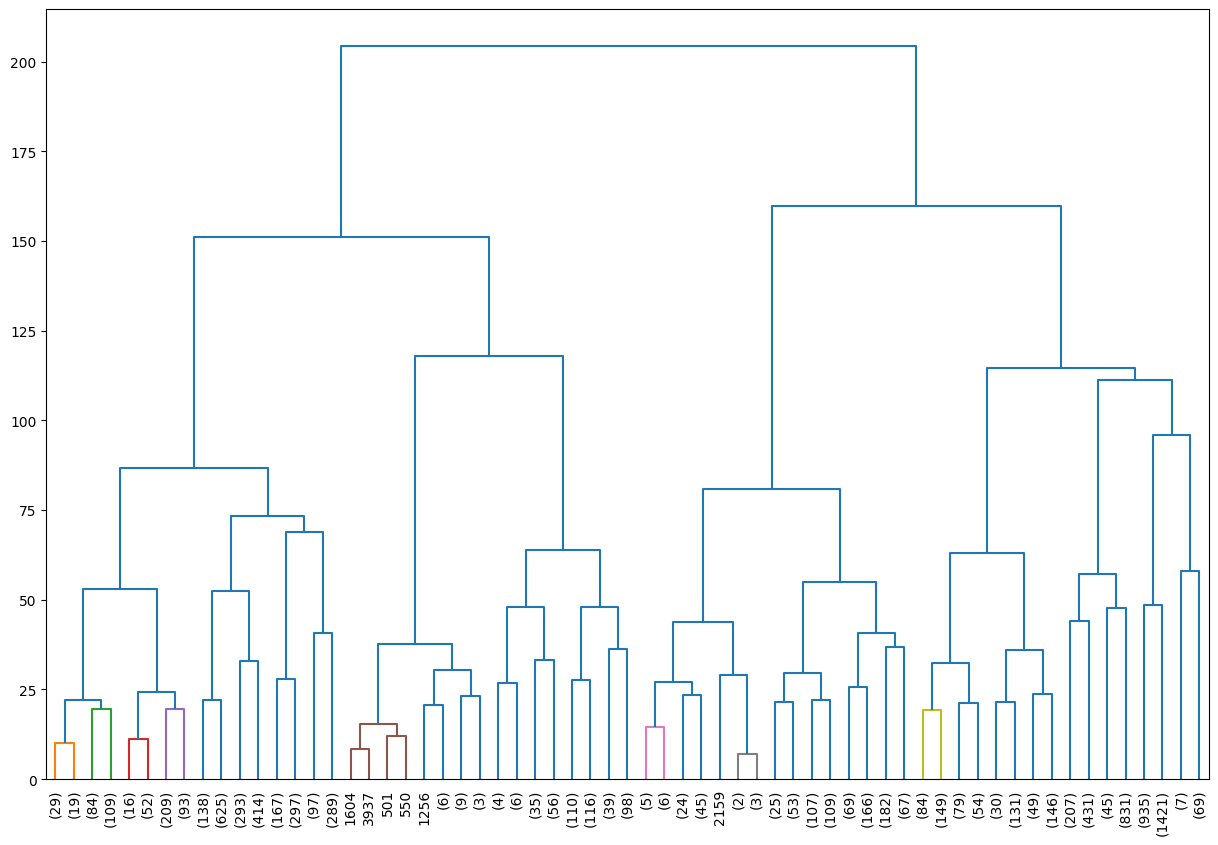

In [ ]:
# ==================== VISUALISASI DATA ====================
# 1. Diagram dendogram
plt.figure(figsize=(15, 10))
dendrogram(linkage(df, method="ward"), leaf_rotation=90, p=5, color_threshold=20, leaf_font_size=10, truncate_mode='level')
plt.show()

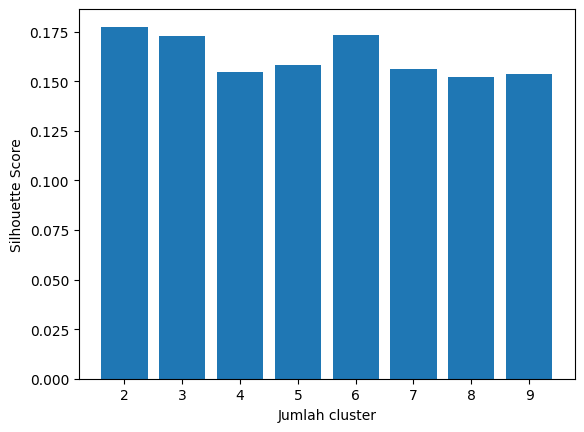

In [ ]:
# 2. Silhouette score
silhouette_scores = []
for n_cluster in range(2, 10):
    silhouette_scores.append(
        silhouette_score(
            df, AgglomerativeClustering(n_clusters = n_cluster).fit_predict(df)
        ) # Silhouette_score()
    ) # Silhouette_scores.append()
plt.bar(range(2, 10), silhouette_scores)
plt.xlabel('Jumlah cluster')
plt.ylabel('Silhouette Score')
plt.show()

In [ ]:
# 3. Agglomerative clustering dengan jumlah cluster = 3
"""
Disini dilakukan clustering menggunakan metode Hierarchical Clustering
dengan jumlah cluster 3.
"""
agglo = AgglomerativeClustering(n_clusters=3)
agglo.fit(df)
labels = agglo.labels_
hasil_agglo = pd.concat([df, pd.DataFrame({'cluster':labels})], axis=1)
hasil_agglo.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960433,-0.528979,-3.109675e-01,-0.525551,0.36068,1
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688639,0.818642,8.931021e-02,0.234227,0.36068,2
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826062,-0.383805,-1.016632e-01,-0.525551,0.36068,0
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826062,-0.598688,4.878305e-17,-0.525551,0.36068,1
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905464,-0.364368,-2.657913e-01,-0.525551,0.36068,1


In [ ]:
# Memilih data berdasarkan kriteria
kondisi = (hasil_agglo['cluster'] == 0)
data_terpilih = hasil_agglo[kondisi]
jumlah_data = len(data_terpilih)
print(f'\njumlah data pada cluster 0:{jumlah_data}')

kondisi = (hasil_agglo['cluster'] == 1)
data_terpilih = hasil_agglo[kondisi]
jumlah_data1 = len(data_terpilih)
print(f'\njumlah data pada cluster 1:{jumlah_data1}')

kondisi = (hasil_agglo['cluster'] == 2)
data_terpilih = hasil_agglo[kondisi]
jumlah_data2 = len(data_terpilih)
print(f'\njumlah data pada cluster 2:{jumlah_data2}')


jumlah data pada cluster 0:3418

jumlah data pada cluster 1:4668

jumlah data pada cluster 2:864


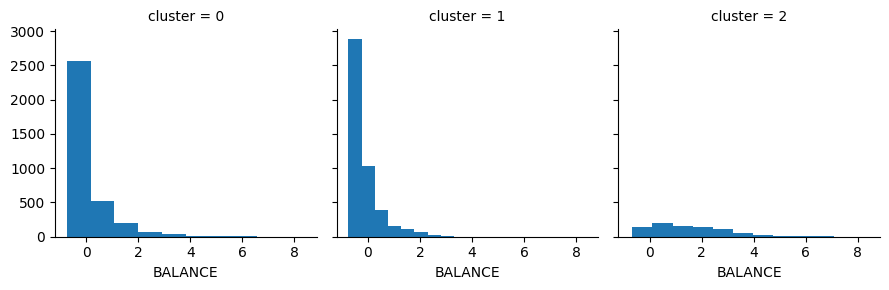

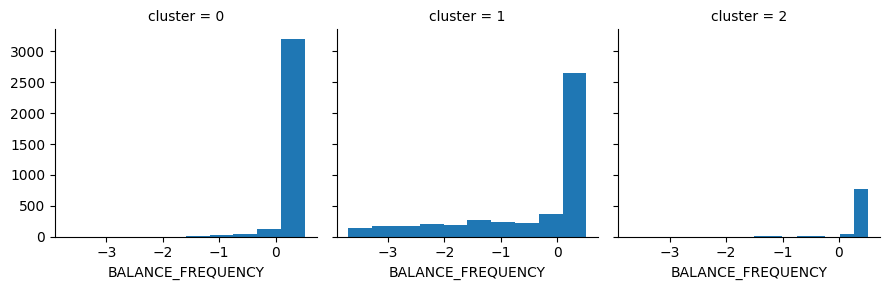

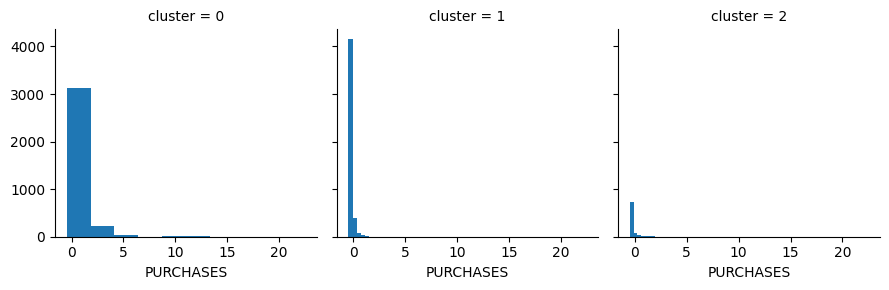

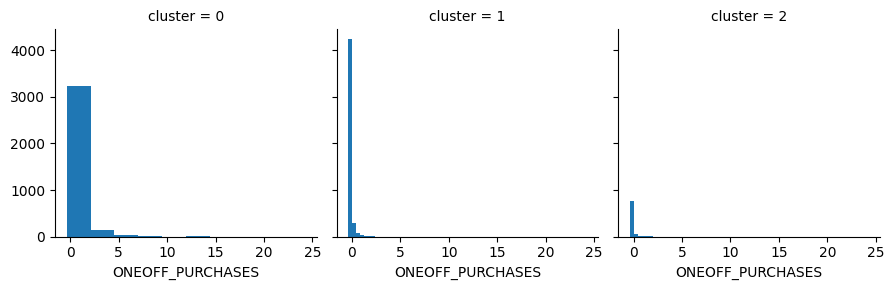

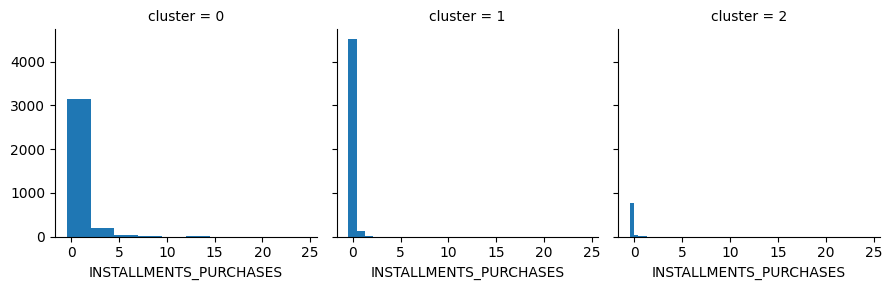

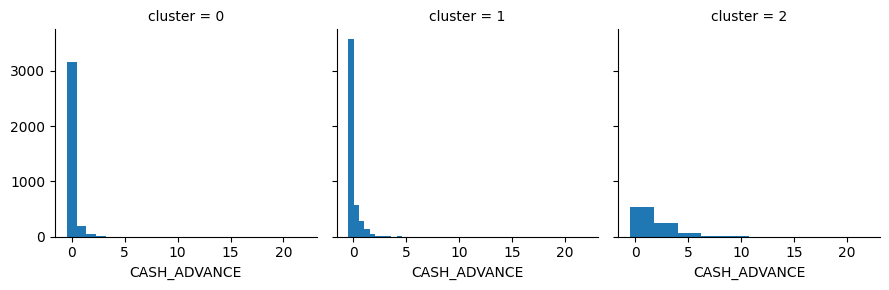

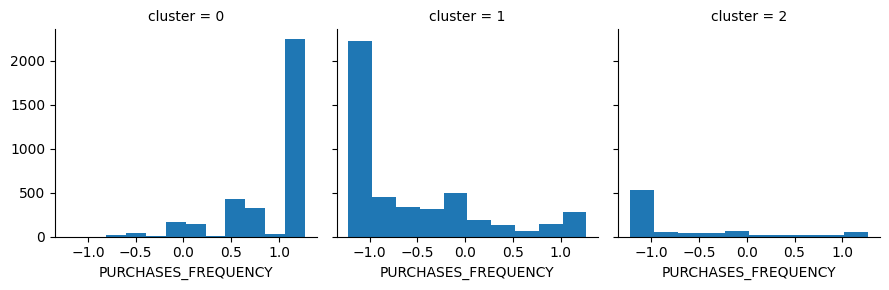

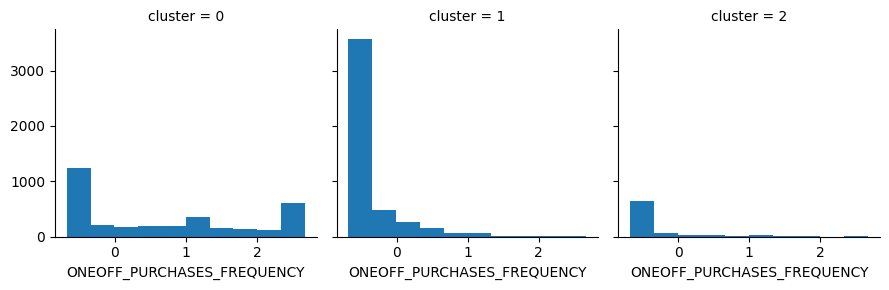

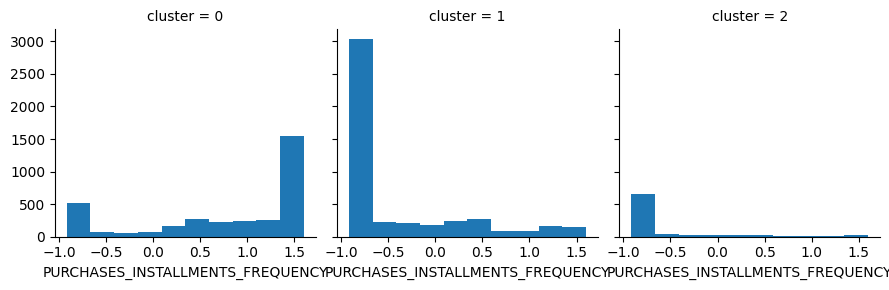

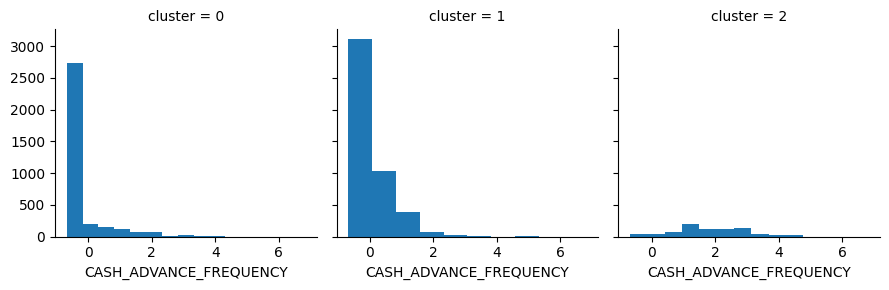

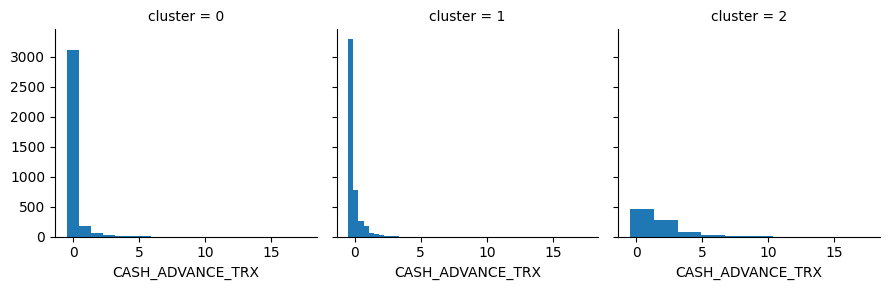

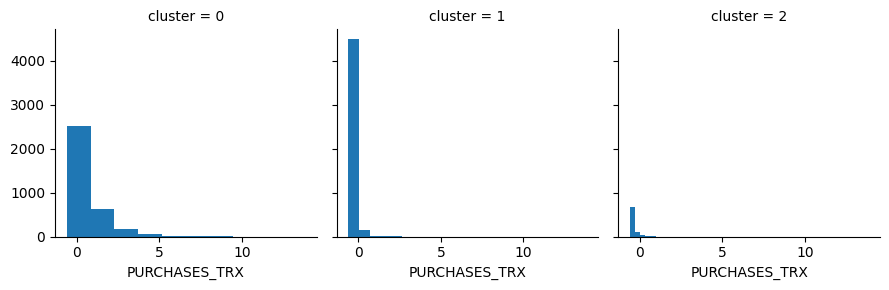

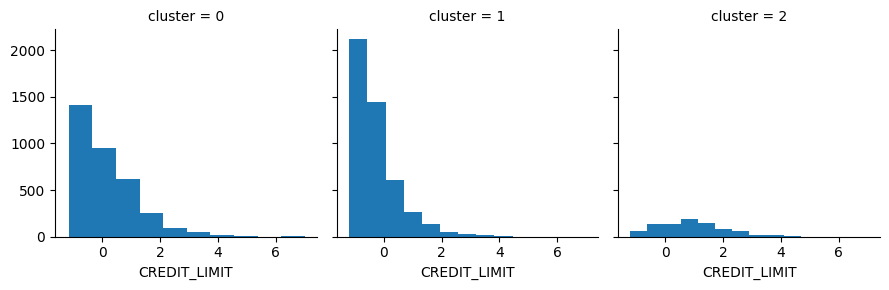

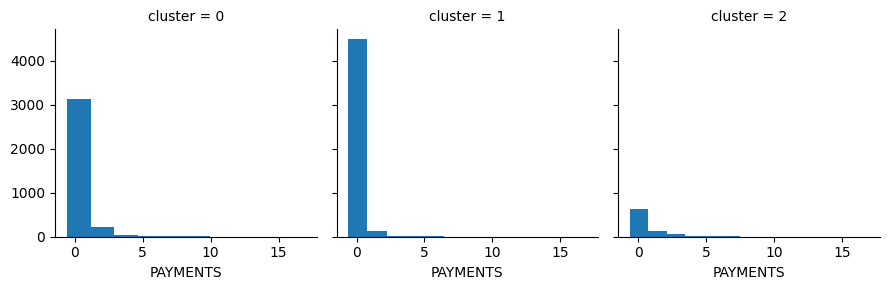

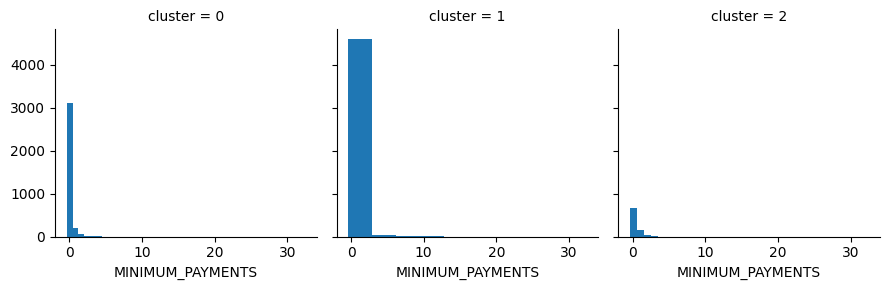

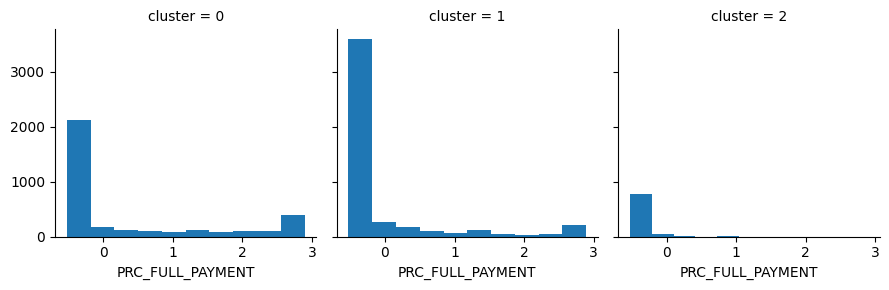

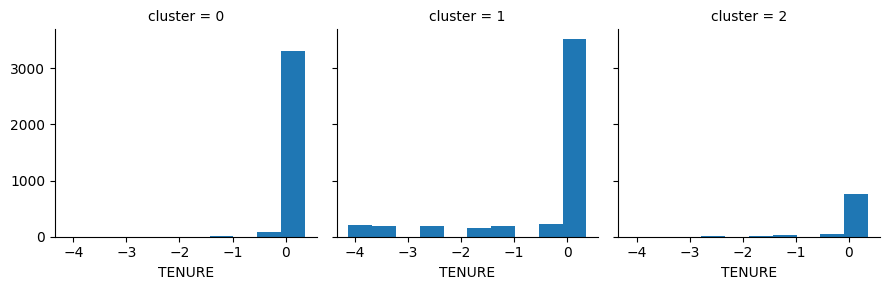

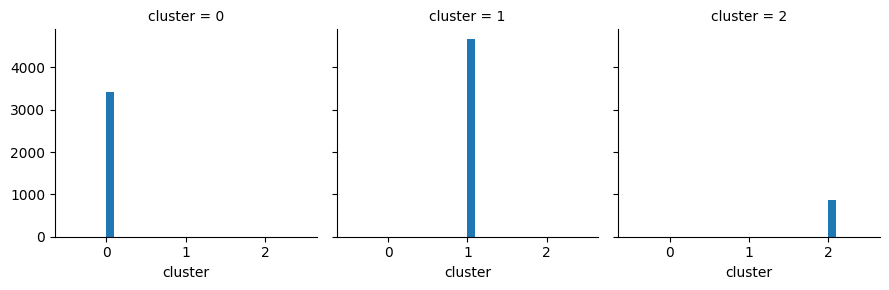

In [ ]:
# 4. Visualisasi hasil agglomerative clustering
""" Disini dilakukan visualisasi frekuensi nilai suatu fitur dari masing-masing cluster. """
for i in hasil_agglo:
    grid = sns.FacetGrid(hasil_agglo, col='cluster')
    grid.map(plt.hist, i)

In [ ]:
# 5. Dekomposisi PCA
dist = 1 - cosine_similarity(df)
pca = PCA(n_components = 2)
pca = pca.fit_transform(dist)

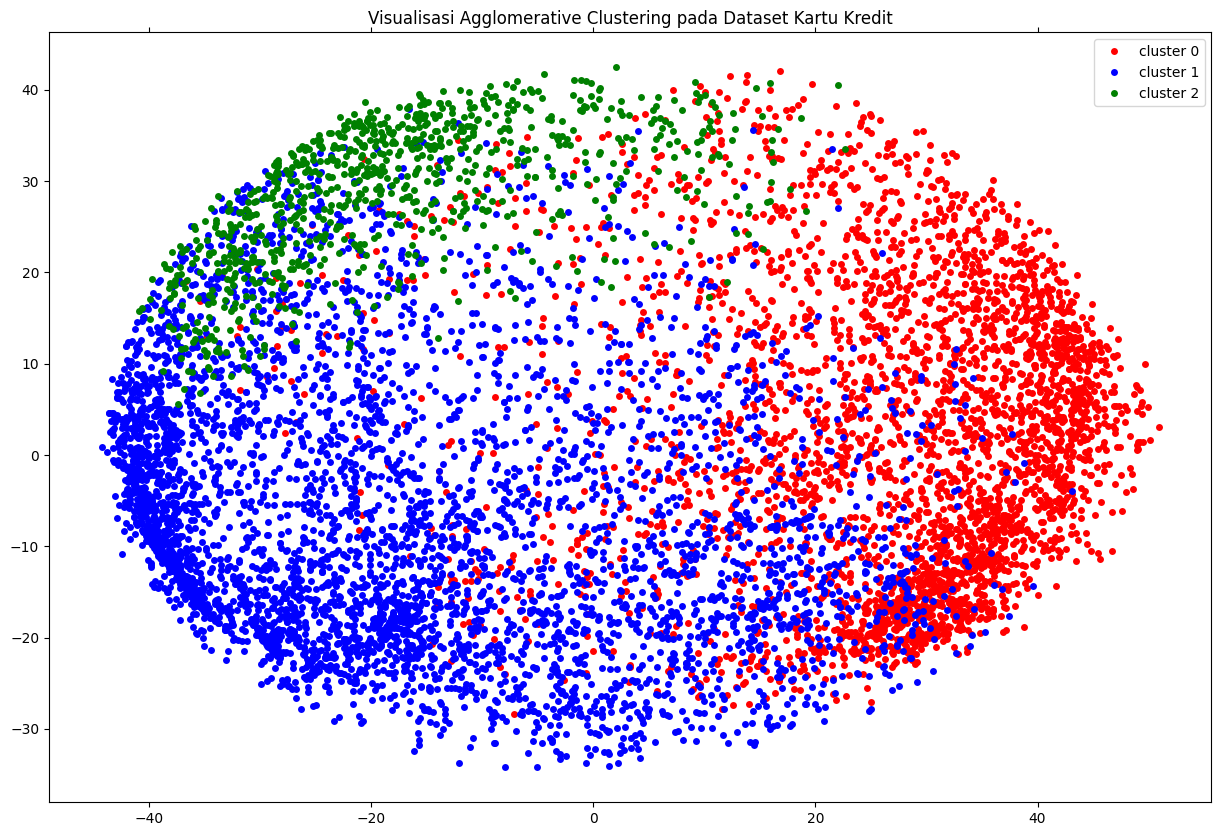

In [ ]:
# 6. Visualisasi penyebaran agglomerative clustering
x, y = pca[:, 0], pca[:, 1]
warna = { 0 : 'red', 1 : 'blue', 2 : 'green'}
label_pca = { 0 : 'cluster 0', 1 : 'cluster 1', 2 : 'cluster 2'}
df = pd.DataFrame({'x' : x, 'y' : y, 'label' : labels})
groups = df.groupby('label')
fig, ax = plt.subplots(figsize=(15, 10))

for name, group in groups:
    ax.plot(group.x, group.y, marker='o', linestyle='', ms=5, color = warna[name], label = label_pca[name], mec='none')
    ax.set_aspect('auto')
    ax.tick_params(axis='x', which='both', bottom='off', top='off', labelbottom='off')
    ax.tick_params(axis='y', which='both', left='off', top='off', labelleft='off')

ax.legend()
ax.set_title("Visualisasi Agglomerative Clustering pada Dataset Kartu Kredit")
plt.show()